In [2]:
import numpy as np
from pathlib import Path
import os, json
import matplotlib.pyplot as plt
cwd = Path.cwd()
import seaborn as sns

from groupBMC.groupBMC import GroupBMC

repo_root = Path("/home/thardy/elefanto/ConsciousnessTeam_Data/SOUNDMODEL/Data_SoundGOOD/LEAD_ExperimentalFolder")
os.chdir(repo_root)

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))
os.environ["PYTHONPATH"] = str(repo_root) + os.pathsep + os.environ.get("PYTHONPATH", "")

import LEAD as lead


# Important variables
SNRs = np.array([-np.inf,-13,-11,-9,-7,-5,-3])
SubIDs = ['01','02','03','05','06','07','08','09','11','12','13','14','15','17','19','20','22','23','24','25']
colormap = {0: (0, 0, 0), 1: (0, 0.25, 1), 2: (0, 0.9375, 1), 3: (0, 0.91, 0.1), 4: (1, 0.6, 0), 5: (1, 0, 0), 6: (0.8, 0, 0)}

Active late


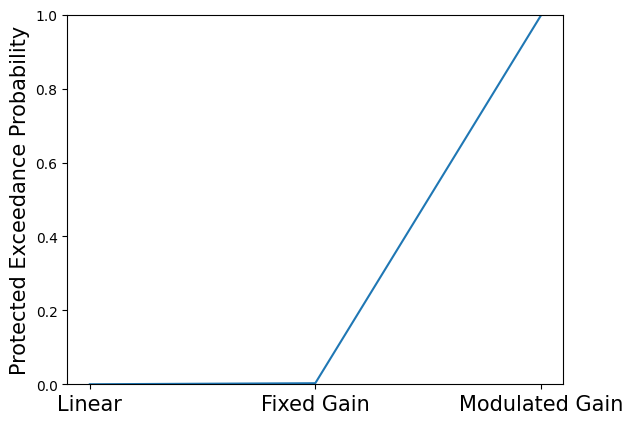

Active early


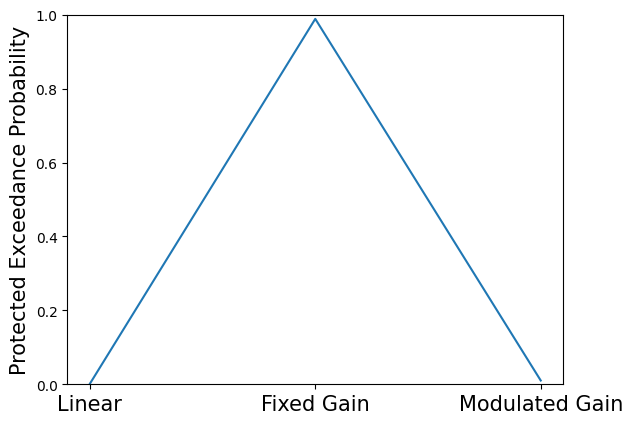

Passive late


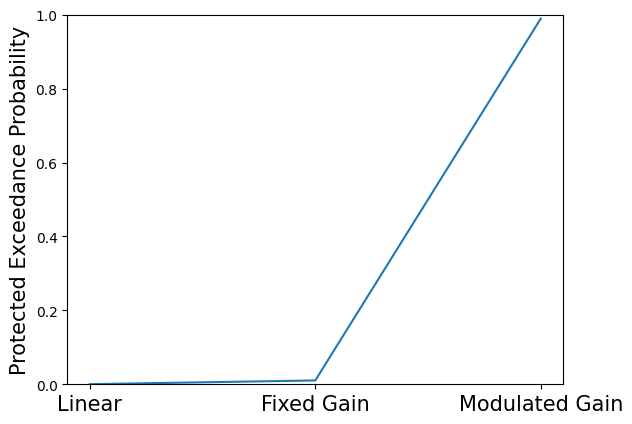

Passive early


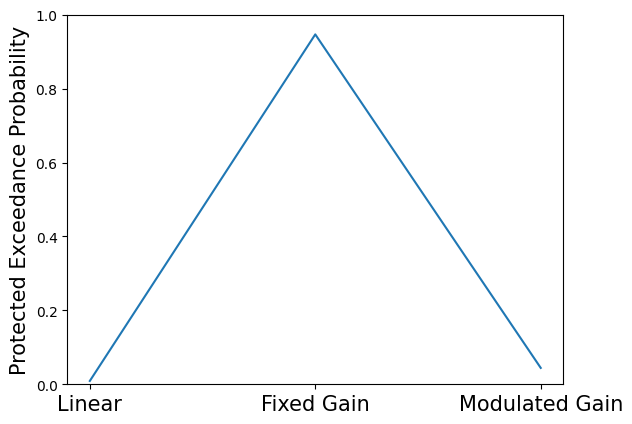

In [ ]:
checkpoints = [('Active', 'late', f'5CV_Active_late.json'),
               ('Active', 'early', f'5CV_Active_early.json'),
               ('Passive', 'late', f'5CV_Passive_late.json'),
               ('Passive', 'early', f'5CV_Passive_early.json')]


for (task, stage, checkpoint_path) in checkpoints:
    print(task, stage)
     
    with open(checkpoint_path, "r") as f:
        checkpoint = json.load(f)
    detailed = checkpoint["detailed"]

    linear_ll, nonlinear_ll, gainmodul_ll = [], [], []
    for detail in detailed:
        linear_ll.append(detail['ll_linear_mean'])
        nonlinear_ll.append(detail['ll_nonlinear_mean'])
        gainmodul_ll.append(detail['ll_gainmod_mean'])
    L = np.array([linear_ll, nonlinear_ll, gainmodul_ll])

    result = GroupBMC(L).get_result()

    _, ax = plt.subplots()
    ax.plot(np.arange(len(L)), result.protected_exceedance_probability)
    ax.set_xticks([0, 1, 2])
    ax.set_xticklabels(['Linear', 'Fixed Gain', 'Modulated Gain'], fontsize=15)
    # ax.set_xlabel('Model')
    ax.set_ylim(0, 1)
    ax.set_ylabel('Protected Exceedance Probability', fontsize=15)
    # plt.savefig(f'Results_EEG_v{version}/{task}/{stage}/ProtectedExceedanceProbability.png')
    plt.show()


    # _, ax = plt.subplots()
    # ax.errorbar(np.arange(len(L)), result.frequency_mean, result.frequency_var)
    # ax.set_xticks([0, 1, 2])
    # ax.set_xticklabels(['Linear', 'Fixed Gain', 'Modulated Gain'], fontsize=15)
    # # ax.set_xlabel('Model')
    # ax.set_ylim(0, 1)
    # ax.set_ylabel('Posterior Model Frequency', fontsize=15)
    # plt.savefig(f'Results_EEG_v{version}/{task}/{stage}/PosteriorModelFrequency.png')
    # plt.show()
        